In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [50]:
url_ic = "https://huggingface.co/datasets/mehmetdavut/RubyCraft-3.4-Eval-Logs/resolve/main/ic_before_after.csv"
df = pd.read_csv(url_ic)

df_models = df[
    df["model"].str.contains("lora", case=False) &
    ~df["model"].str.contains("base", case=False)
].copy()

In [51]:
def get_architecture(model_name):
    name = model_name.lower()
    if "qwen" in name and "coder" in name: return "Qwen-Coder"
    elif "qwen" in name: return "Qwen (Base)"
    elif "llama" in name: return "Llama"
    elif "gemma" in name: return "Gemma"
    elif "phi" in name: return "Phi"
    else: return "Other"

def get_tier(model_name):
    name = model_name.lower()
    if any(size in name for size in ["7b", "8b", "9b", "big"]):
        return "Big (≥ 7B)"
    elif "qwen" in name and "coder" in name and "7b" not in name:
        return "Small (< 4B)"
    elif any(size in name for size in ["1.5b", "2b", "3b", "mini", "small"]):
        return "Small (< 4B)"
    else:
        return "Unknown"

df_models["Architecture"] = df_models["model"].apply(get_architecture)
df_models["Tier"] = df_models["model"].apply(get_tier)

df_models = df_models[(df_models["Architecture"] != "Other") & (df_models["Tier"] != "Unknown")]

arch_order = ["Gemma", "Llama", "Phi", "Qwen (Base)", "Qwen-Coder"]

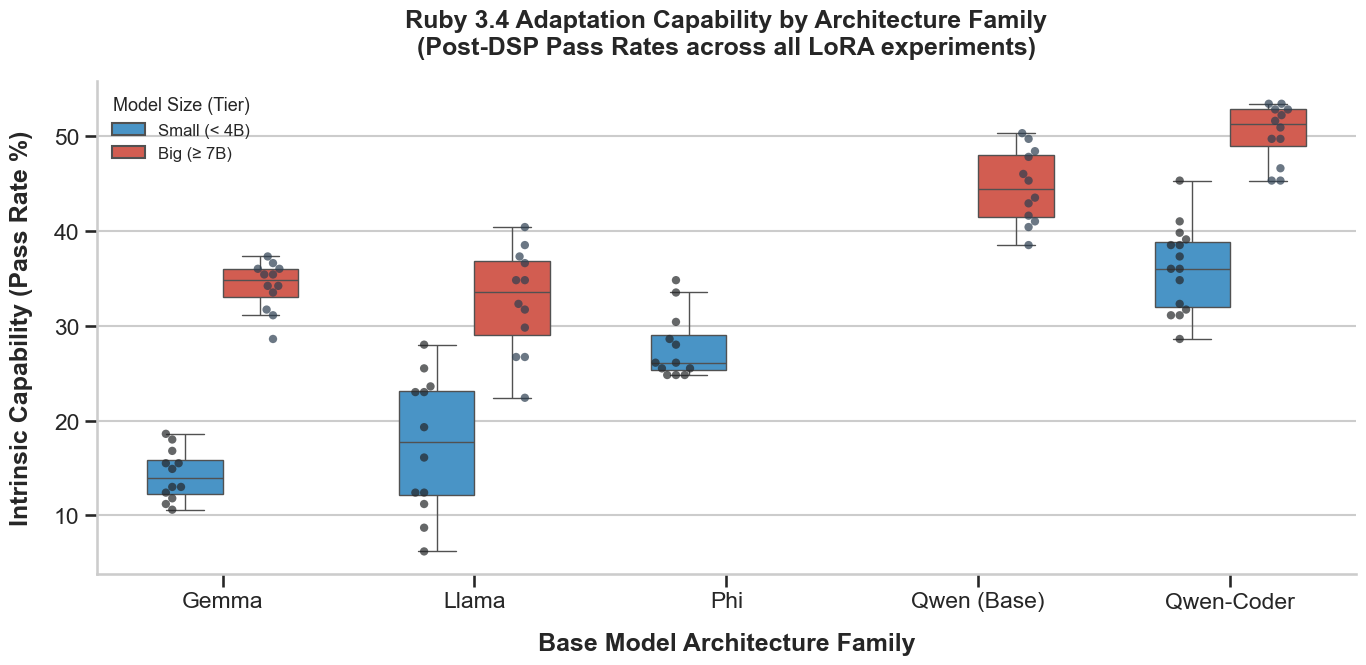

In [52]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df_models,
    x="Architecture",
    y="after_pct",
    hue="Tier",
    order=arch_order,
    palette={"Small (< 4B)": "#3498db", "Big (≥ 7B)": "#e74c3c"},
    showfliers=False,
    width=0.6,
    ax=ax
)

sns.swarmplot(
    data=df_models,
    x="Architecture",
    y="after_pct",
    hue="Tier",
    order=arch_order,
    dodge=True,
    palette='dark:#2c3e50',
    size=6,
    alpha=0.7,
    ax=ax,
    legend=False
)

ax.set_title("Ruby 3.4 Adaptation Capability by Architecture Family\n(Post-DSP Pass Rates across all LoRA experiments)", fontweight="bold", pad=20)
ax.set_xlabel("Base Model Architecture Family", fontweight="bold", labelpad=15)
ax.set_ylabel("Intrinsic Capability (Pass Rate %)", fontweight="bold", labelpad=15)

plt.legend(title="Model Size (Tier)", title_fontsize="13", fontsize="12", loc="upper left")

sns.despine()
plt.tight_layout()

In [53]:
import os

os.makedirs("../images", exist_ok=True)
fig.savefig("../images/architecture_comparison_boxplot.png", dpi=300, bbox_inches="tight", facecolor="white")